In [1]:
#@title
#@Import packages
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras as k
import pandas as pd
from google.colab import auth
auth.authenticate_user()
from oauth2client.client import GoogleCredentials
from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/My\ Drive/Colab\ Notebooks/
import gspread as gs
import gspread_dataframe as gsd

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive/
/content/drive/My Drive/Colab Notebooks


In [2]:
%run '/content/drive/My Drive/Colab Notebooks/BA_functions.py'

In [3]:
Datas=binaryalldirections()

# 28th June: Revisiting the CNN; but this time FULLY

In [ ]:
fcn,efcn,dfcn=cnn((2,2000,1))

In [ ]:

    
traindata=fcndata(Datas[0])
print(np.shape(traindata))

(5313, 2, 2000, 1)


NOte: the losses here start around 100.000! So strong convergence

In [ ]:
training(fcn,0.00001,1000,10,traindata,1,1)

In [ ]:
fcn.load_weights('/content/drive/My Drive/Colab Notebooks/Weights/FCN 2nd try Cross 28Jun')

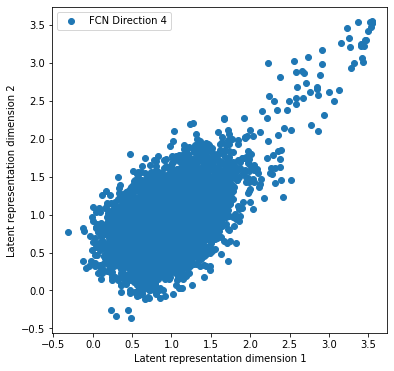

In [ ]:
Datalrep=latrep(efcn,traindata,'FCN Direction 4')
#_=latrepmulti(efcn,[fcndata(Datas[0]),fcndata(Datas[1]),fcndata(Datas[2]),fcndata(Datas[3])],[' Direction4','5','6','7'])



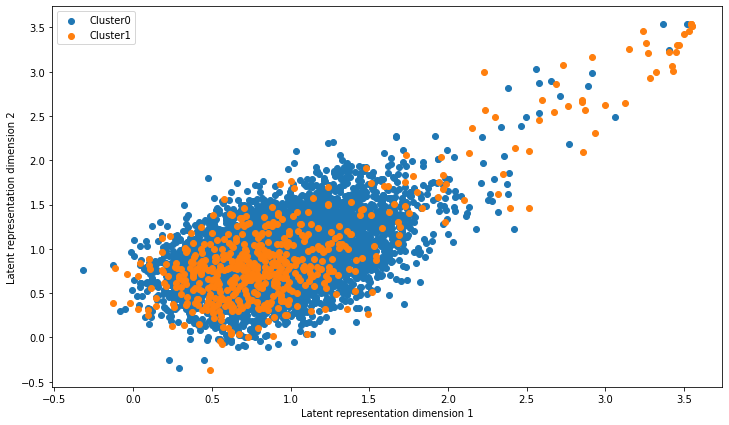

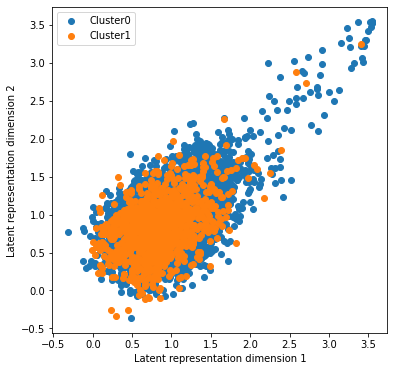

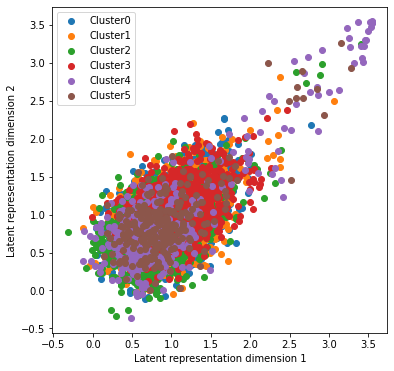

In [ ]:
_=latrepclustered(efcn,a,4)
_=latrepclustered(efcn,a,5)
_=latrepclustered(efcn,a,6)

Index of outlier:
46


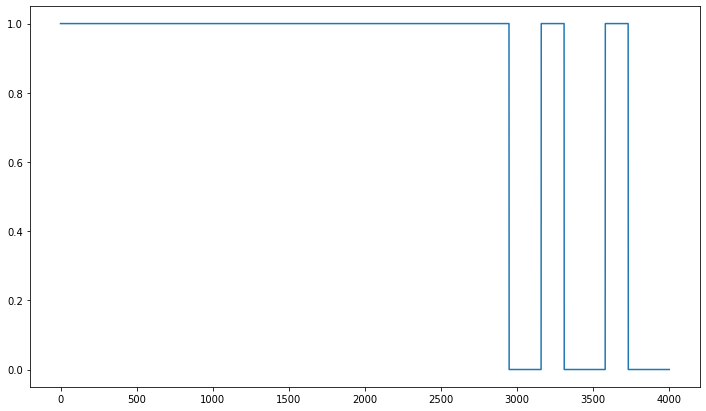

Index of outlier:
95


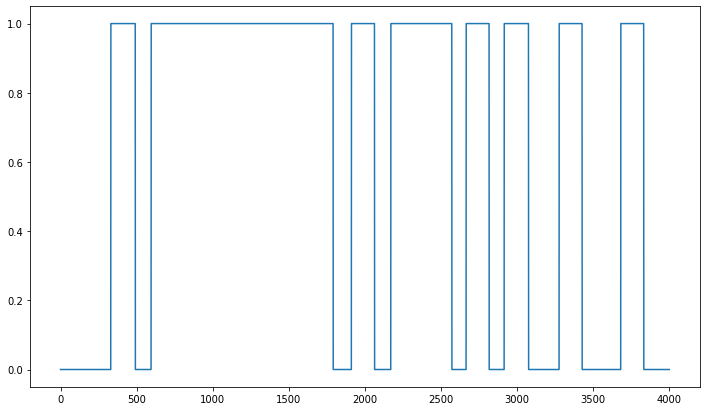

Index of outlier:
177


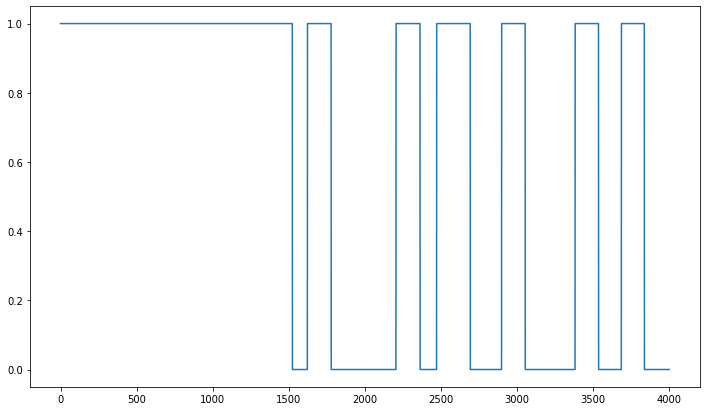

Index of outlier:
310


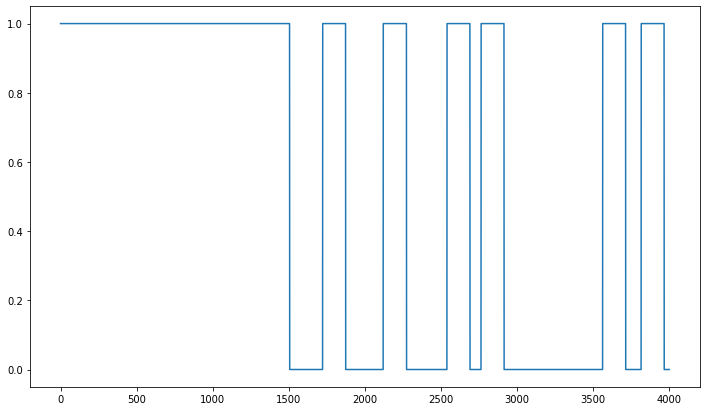

Index of outlier:
1038


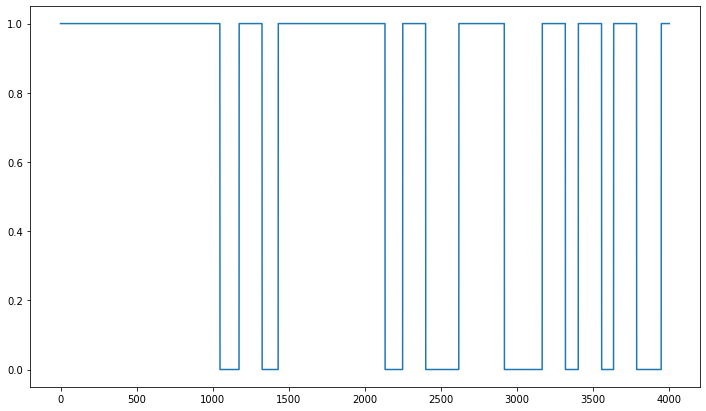

Index of outlier:
1064


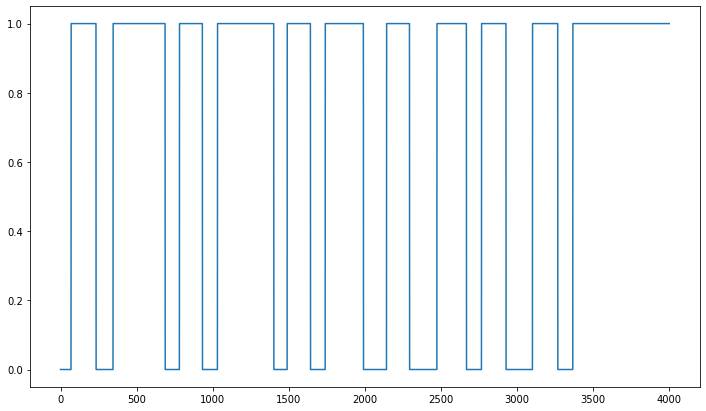

Index of outlier:
1559


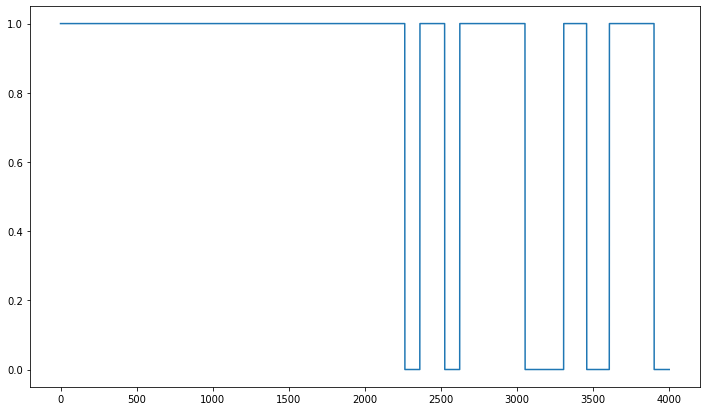

Index of outlier:
1802


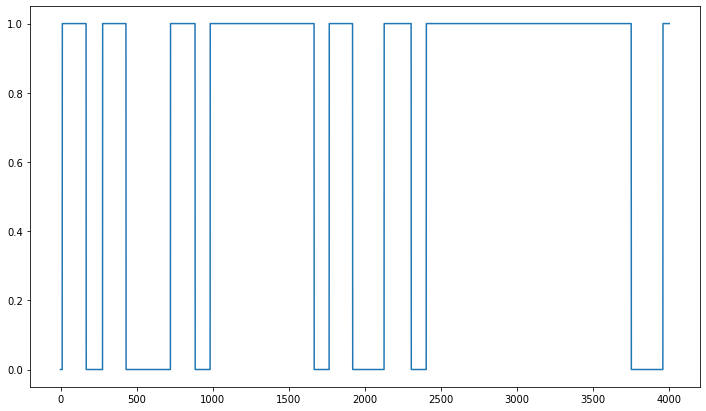

Index of outlier:
1823


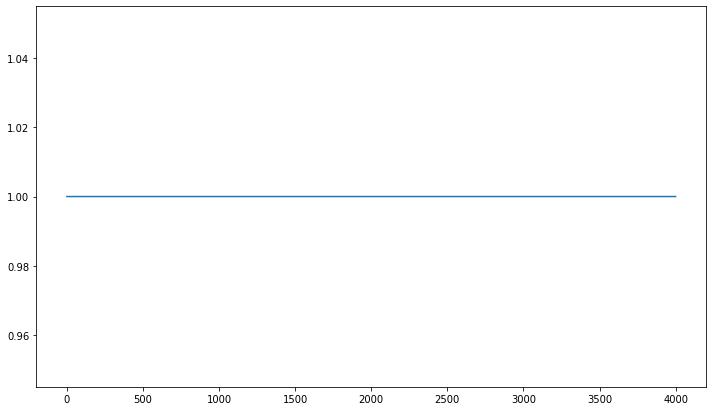

Index of outlier:
1859


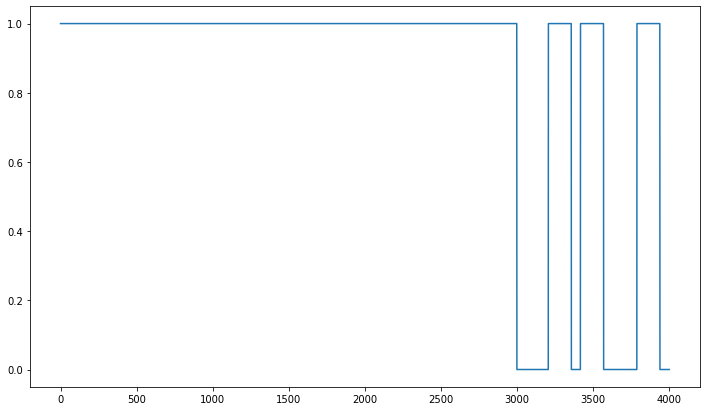

Index of outlier:
1919


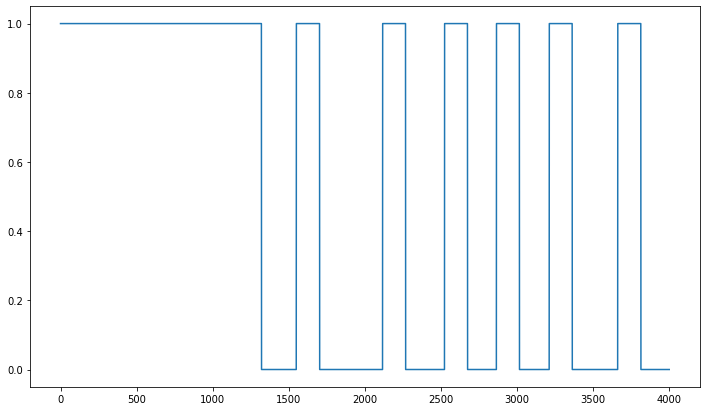

Index of outlier:
2074


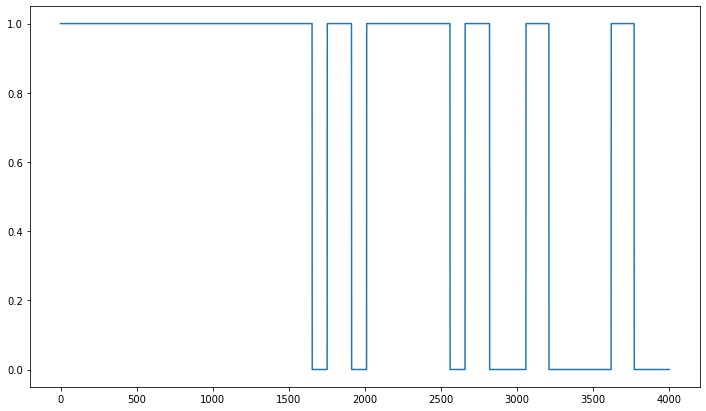

Index of outlier:
2381


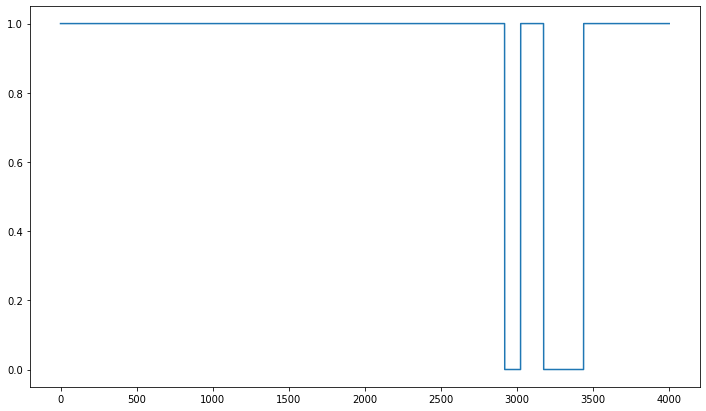

Index of outlier:
2382


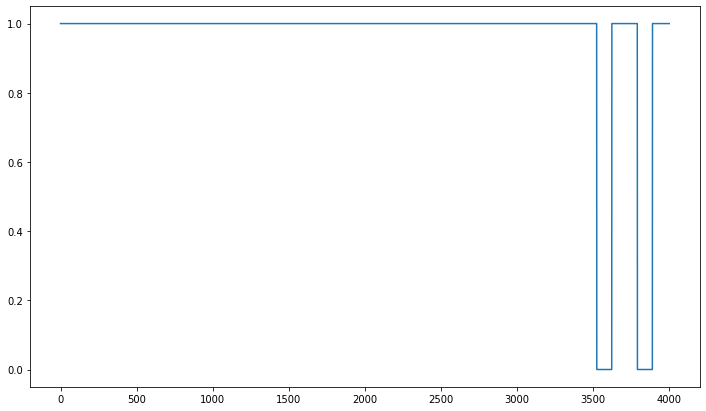

Index of outlier:
2383


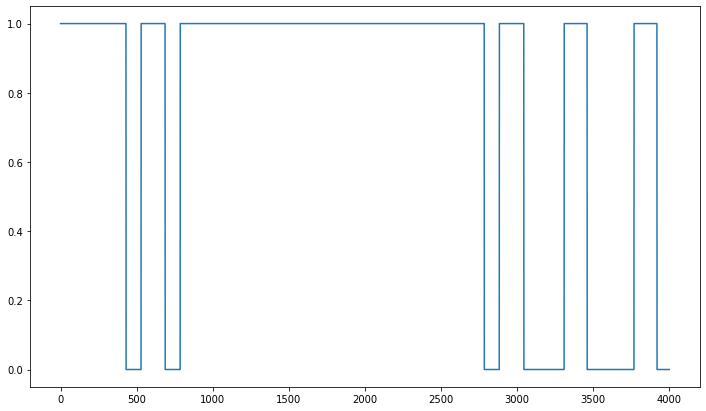

Index of outlier:
2502


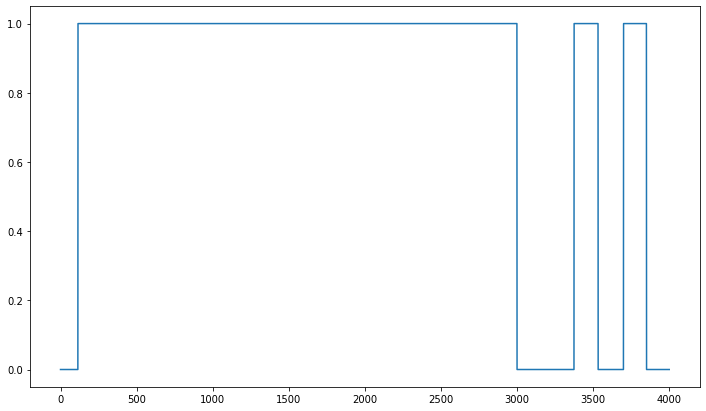

Index of outlier:
2605


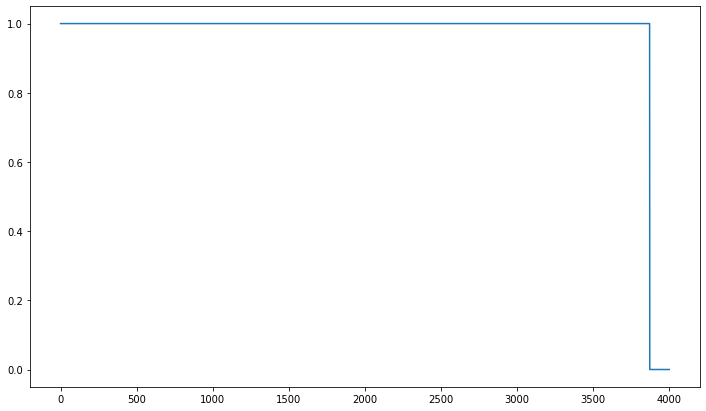

Index of outlier:
2619


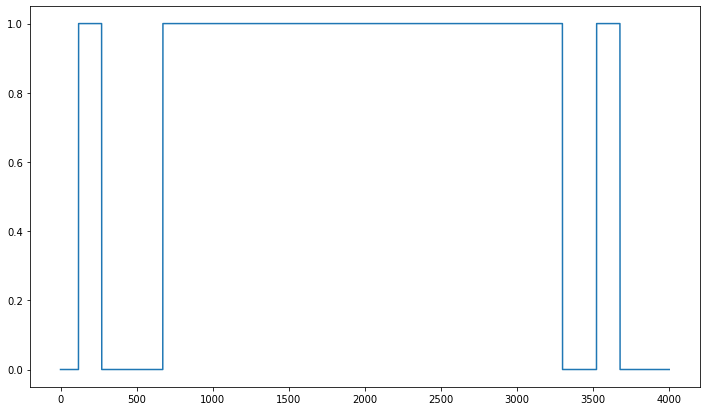

Index of outlier:
2855


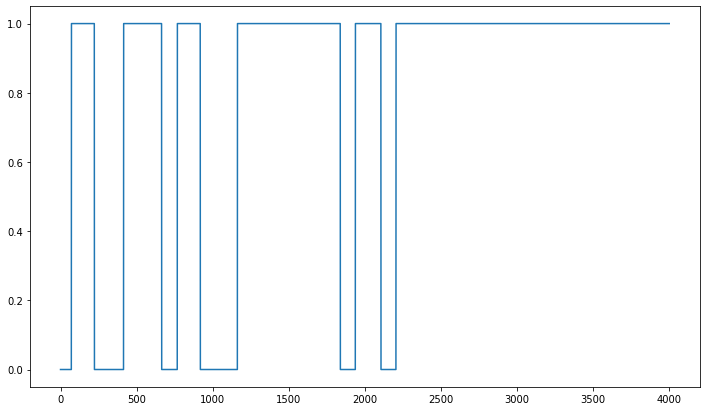

Index of outlier:
2856


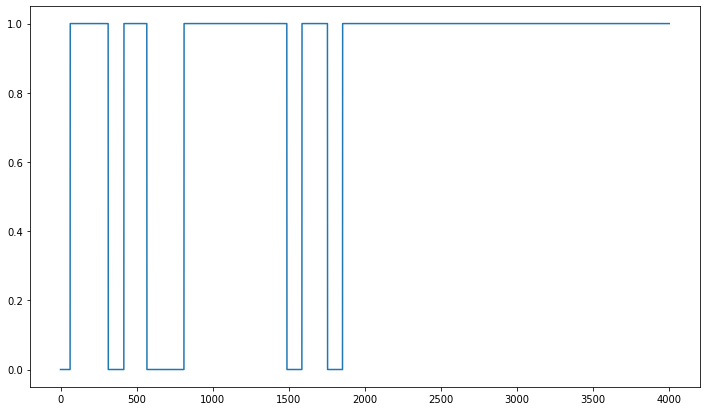

Index of outlier:
2857


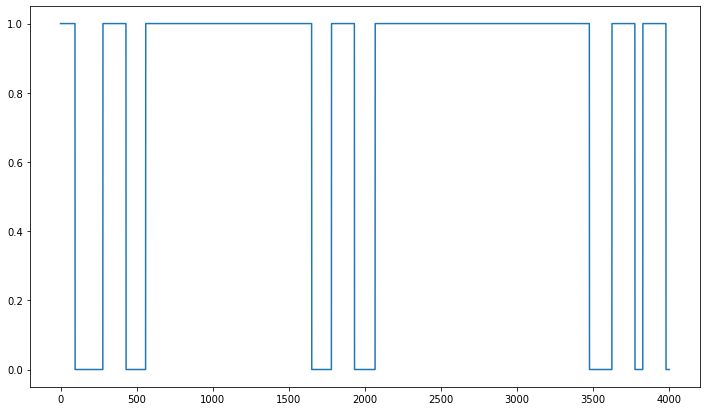

Index of outlier:
2959


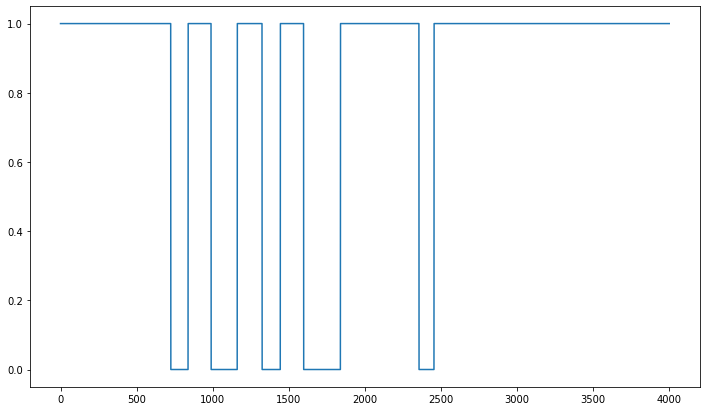

Index of outlier:
2960


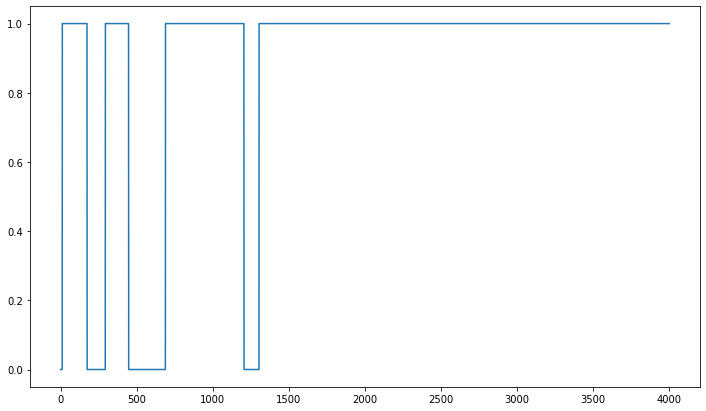

Index of outlier:
2988


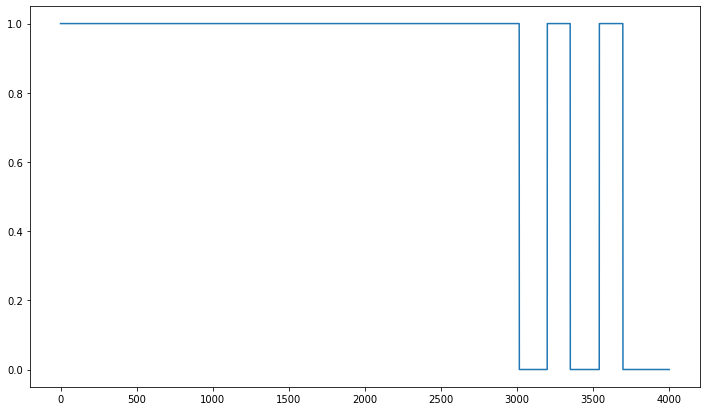

Index of outlier:
3116


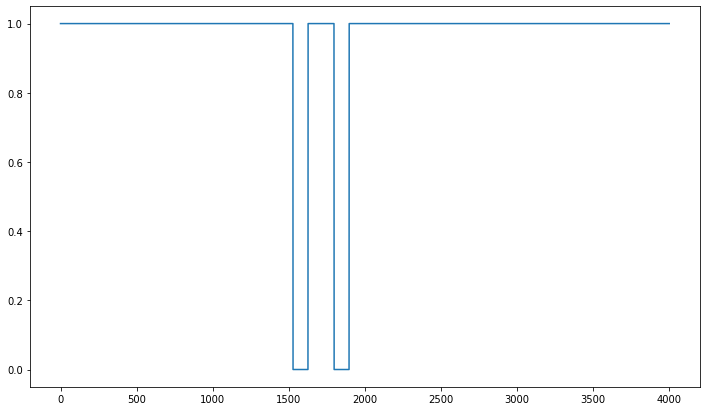

Index of outlier:
3117


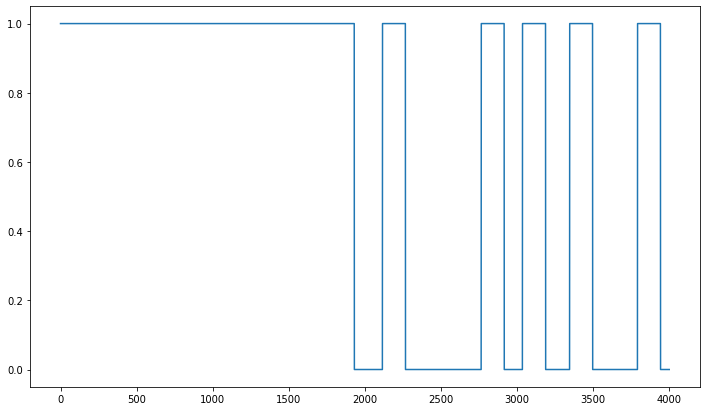

Index of outlier:
3461


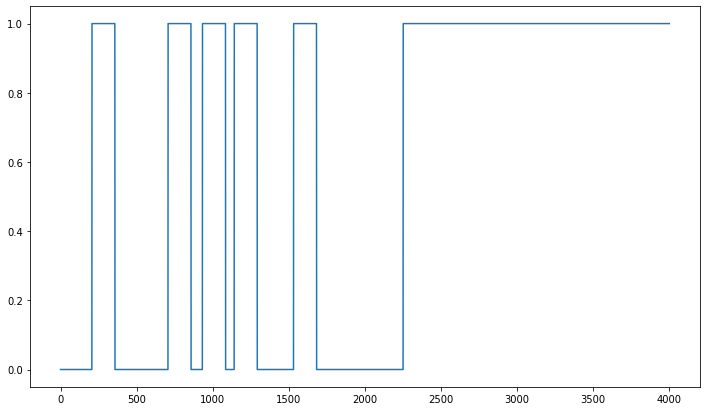

Index of outlier:
3486


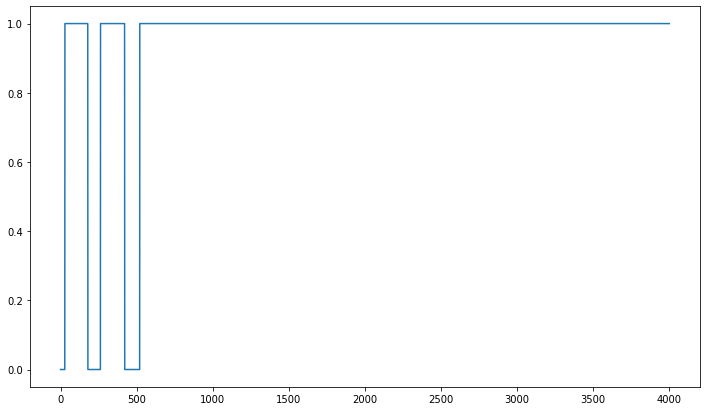

Index of outlier:
3545


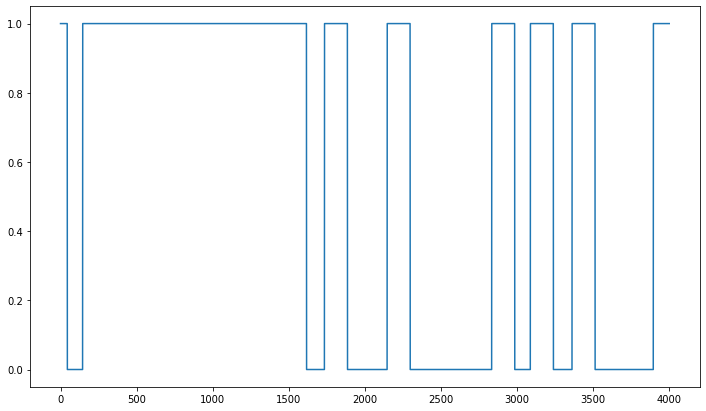

Index of outlier:
3546


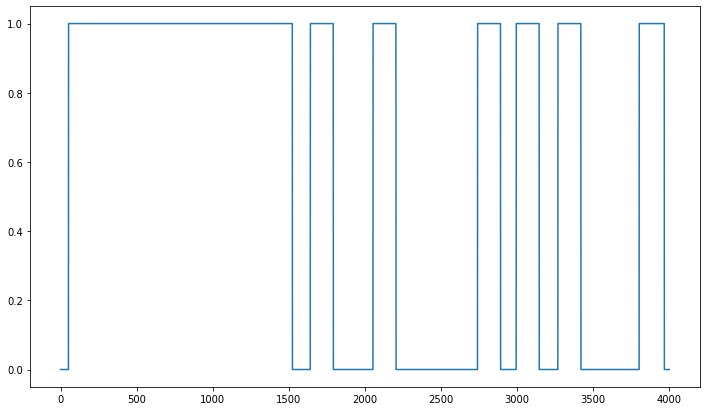

Index of outlier:
3581


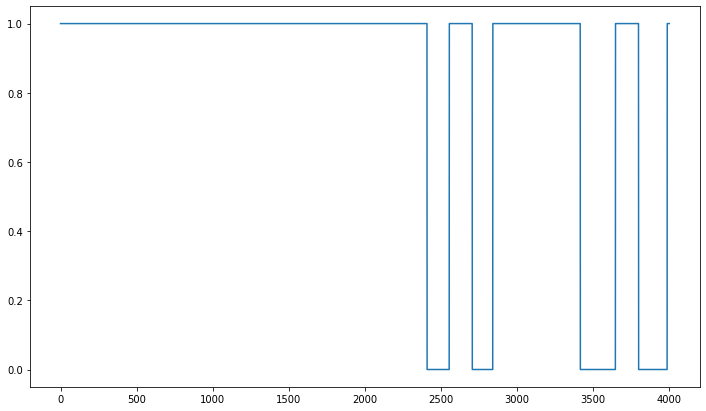

Index of outlier:
3582


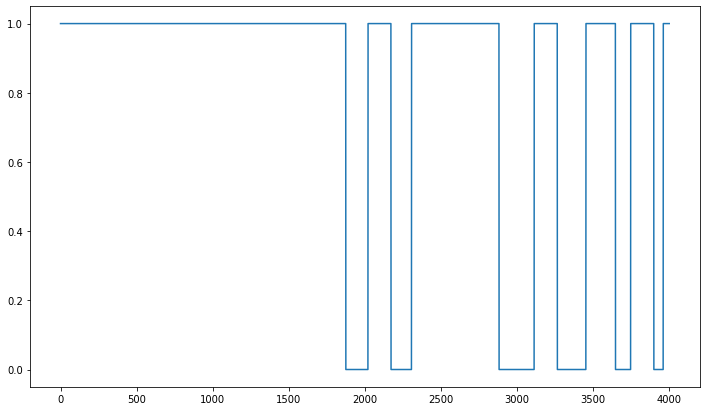

Index of outlier:
3583


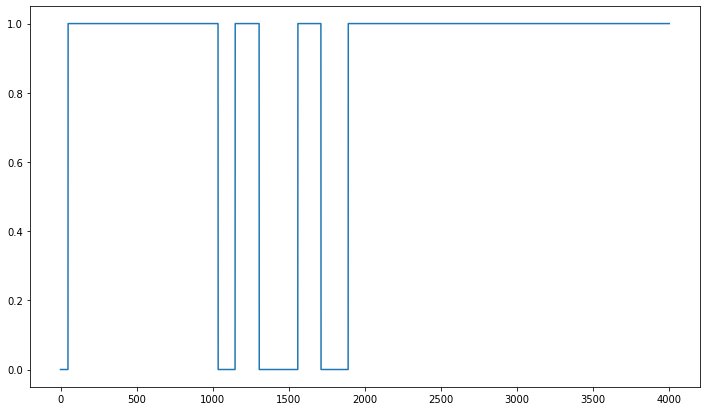

Index of outlier:
3595


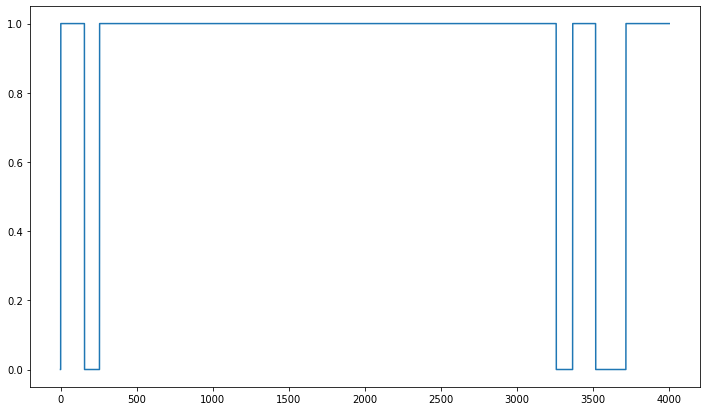

Index of outlier:
3613


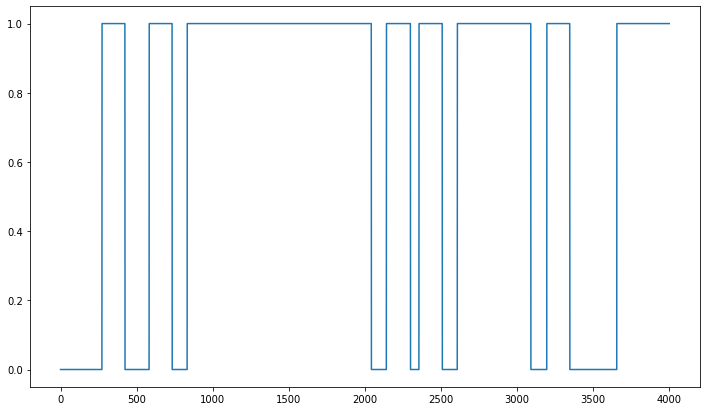

Index of outlier:
3614


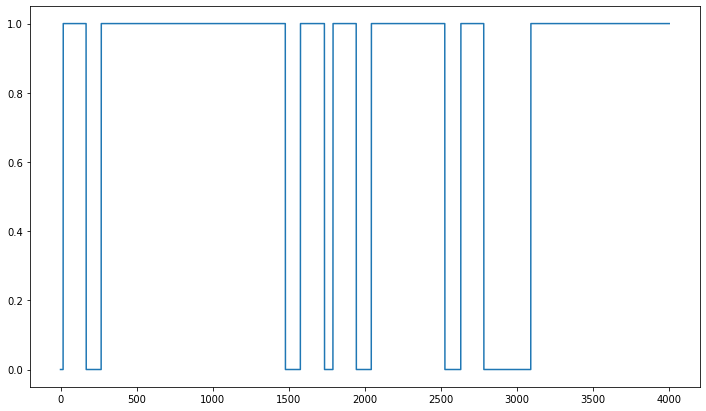

Index of outlier:
3634


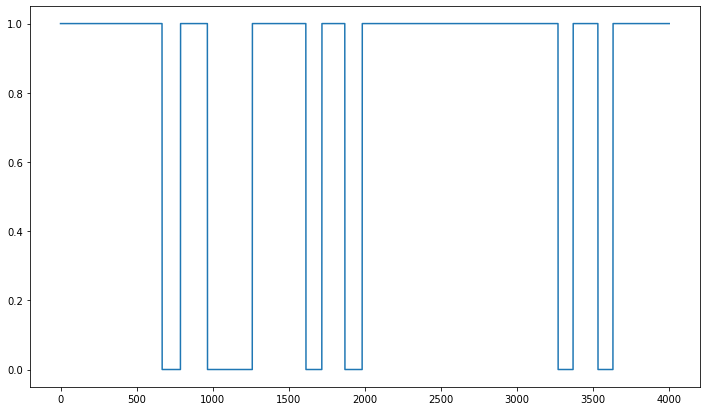

Index of outlier:
3686


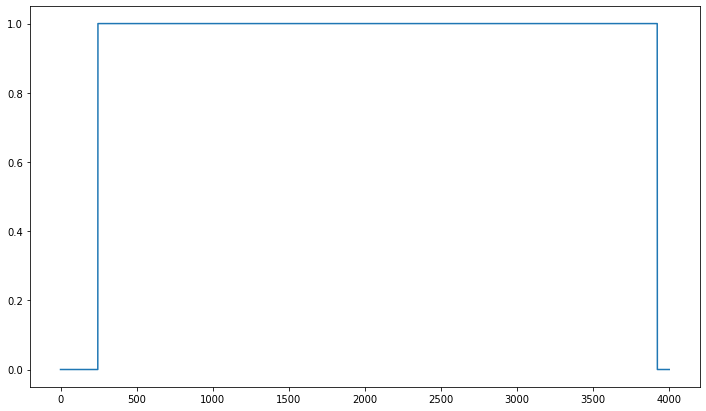

Index of outlier:
3723


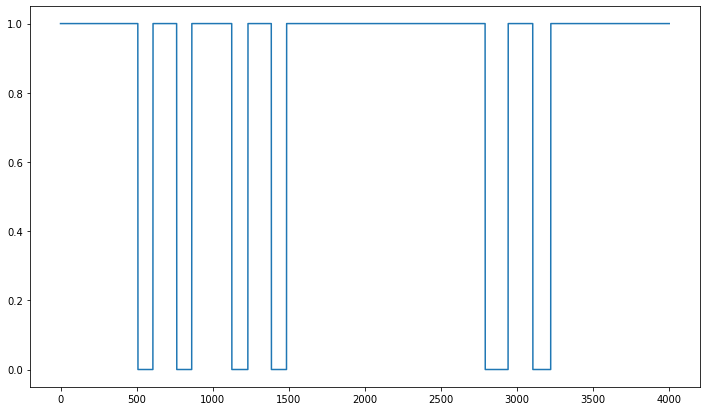

Index of outlier:
3756


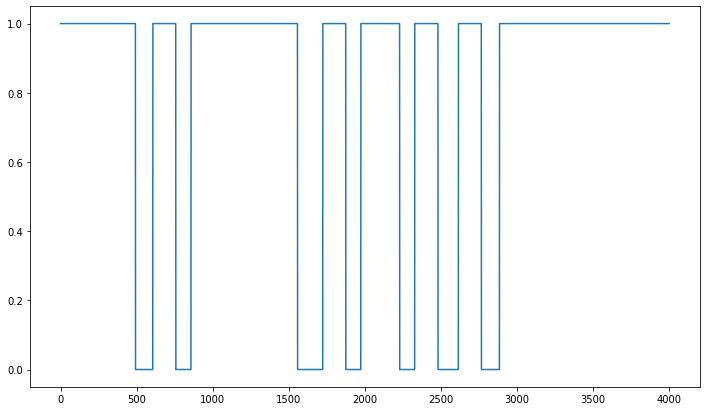

Index of outlier:
3786


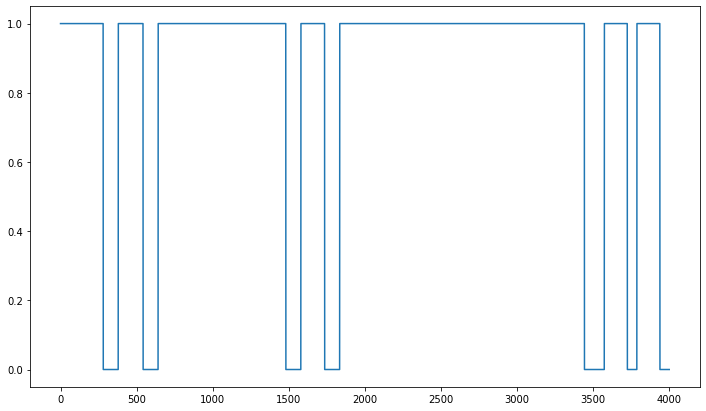

Index of outlier:
3797


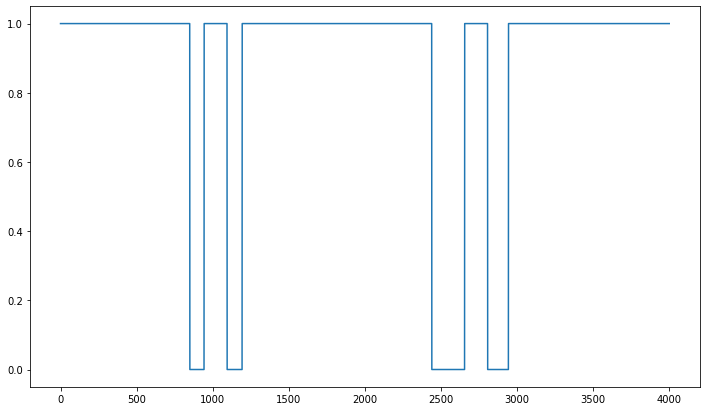

Index of outlier:
3798


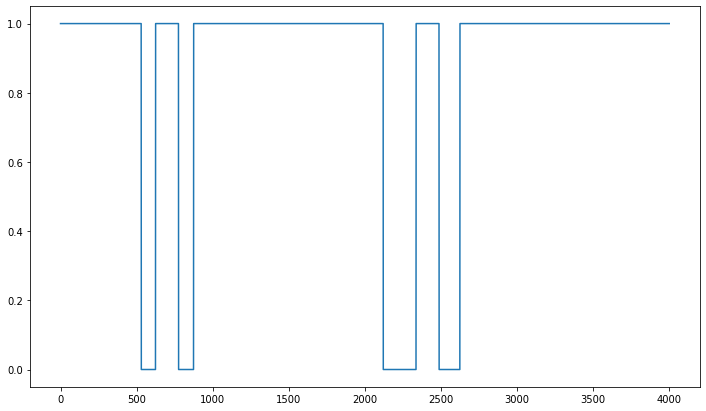

Index of outlier:
4048


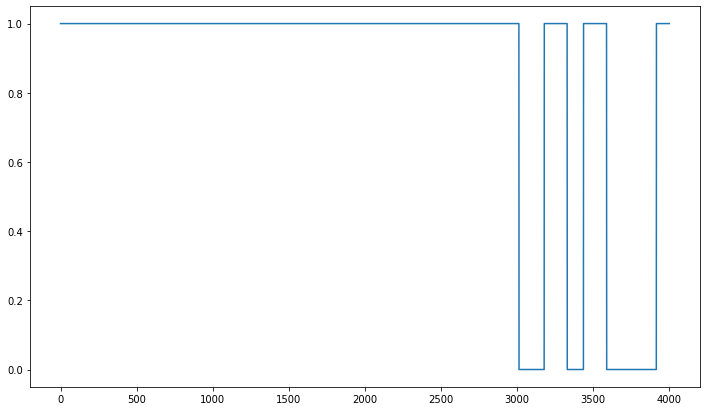

Index of outlier:
4175


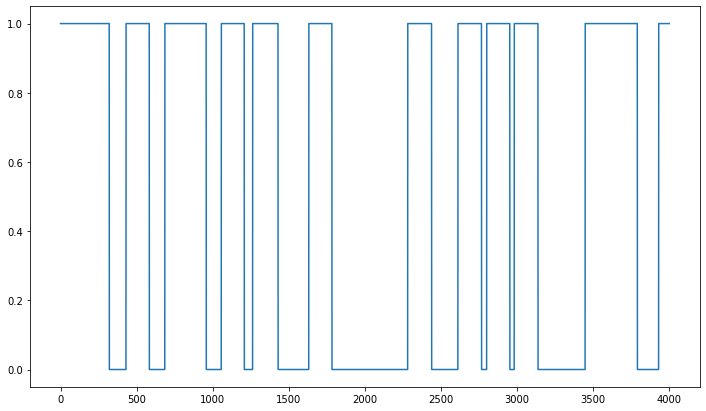

Index of outlier:
4276


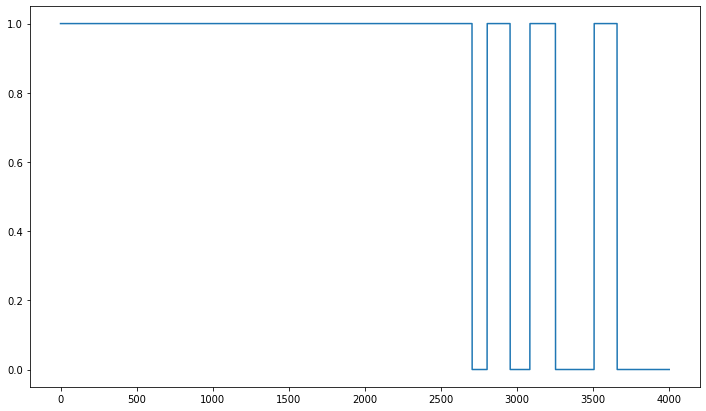

Index of outlier:
4917


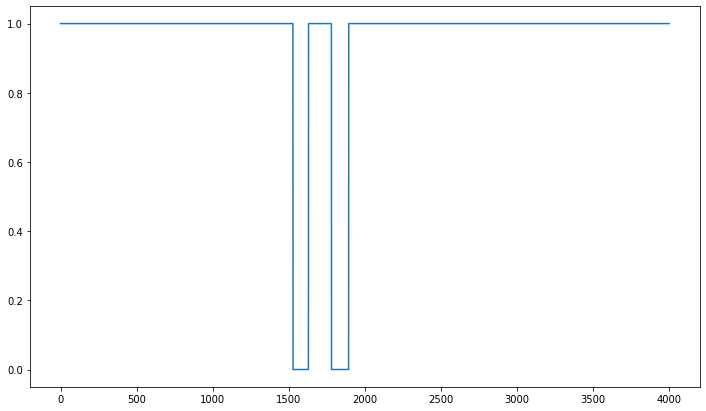

Index of outlier:
5234


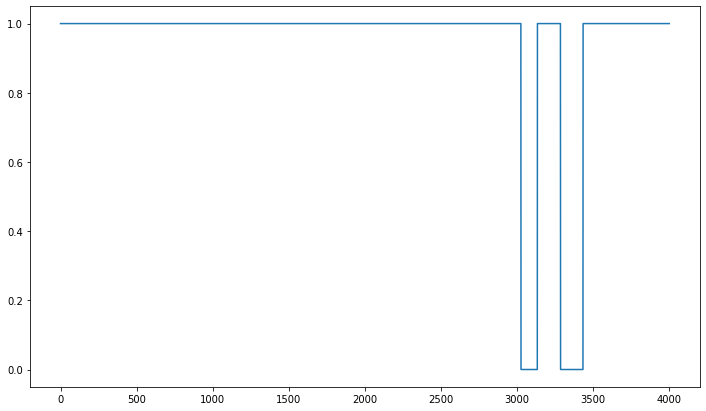

5313


In [ ]:
indices=[]
for n in range(len(Datalrep[0])):
    a=Datalrep[0][n]
    b=Datalrep[1][n]
    if a>2.3:
        if b>2.3:
            #print(ding)
            indices.append(n)
for n in indices:
    print('Index of outlier:')
    print(n)
    plt.plot(Datas[0][n])
    plt.show()
print(len(Datalrep[0]))

## 2nd Training

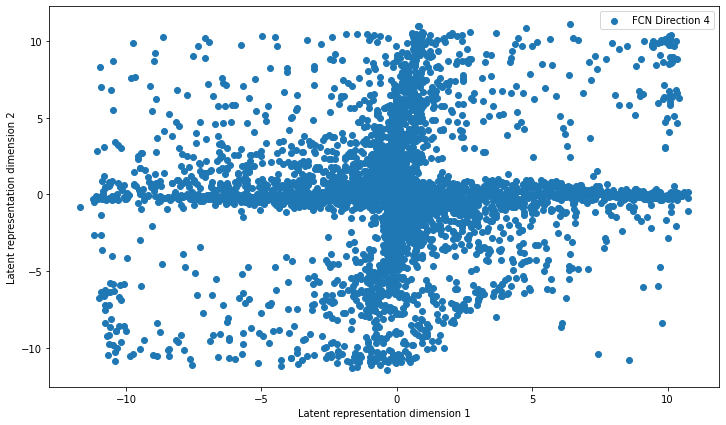

In [ ]:
Datalrep=latrep(efcn,traindata,'FCN Direction 4')
#_=latrepmulti(efcn,[fcndata(Datas[0]),fcndata(Datas[1]),fcndata(Datas[2]),fcndata(Datas[3])],[' Direction4','5','6','7'])



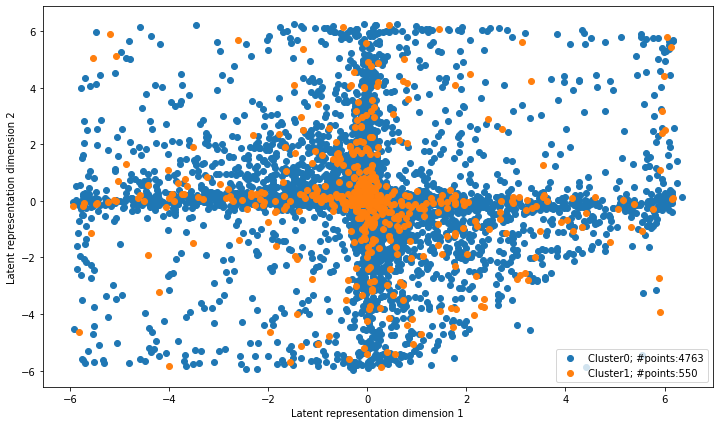

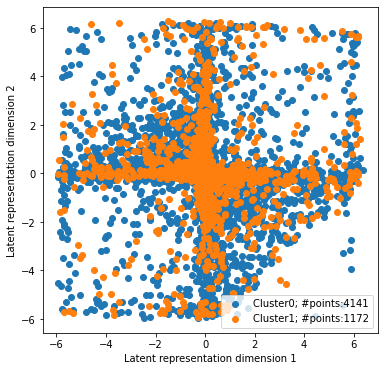

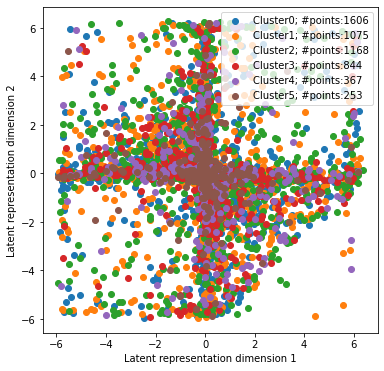

In [ ]:
_=latrepclustered(efcn,traindata,4)
_=latrepclustered(efcn,traindata,5)
_=latrepclustered(efcn,traindata,6)

## Comparing this cross with the largest principal components

(5313, 10)


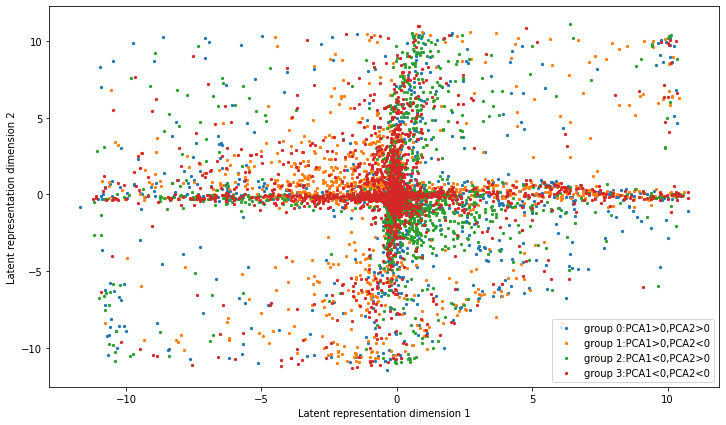

In [ ]:
newrep=directpca(Datas[0],10)
groupsind=[[] for n in range(4)]
groups=[[] for n in range(4)]
print(np.shape(newrep))
for n in range(len(newrep)):
    dp=newrep[n]
    if dp[0]>0:
        if dp[1]>0:
            a=0
        else:
            a=1
    else:
        if dp[1]>0:
            a=2
        else:
            a=3
    groupsind[a].append(n)
    groups[a].append
#groups_=np.array(groups)
#print((groups[0]))
foo=latrepmulti(efcn,[traindata[groupsind[0]],traindata[groupsind[1]],
                      traindata[groupsind[2]],traindata[groupsind[3]]]
                     ,['group 0:PCA1>0,PCA2>0','group 1:PCA1>0,PCA2<0',
                       'group 2:PCA1<0,PCA2>0','group 3:PCA1<0,PCA2<0'])

## Examining the cross


In [5]:
fcn,efcn,dfcn=cnn((2,2000,1))

In [7]:

    
traindata=fcndata(Datas[0],0)
print(np.shape(traindata))

(5313, 2, 2000, 1)


In [8]:
fcn.load_weights('/content/drive/My Drive/Colab Notebooks/Weights/FCN 2nd try Cross 28Jun')

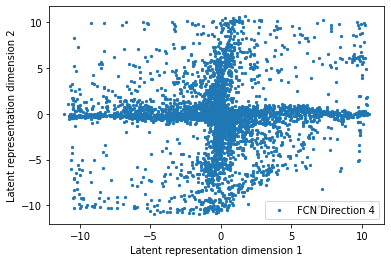

In [9]:
Datalrep=latrep(efcn,traindata,'FCN Direction 4')


 Now we look at how good in general this model recreates the original shape for some examples

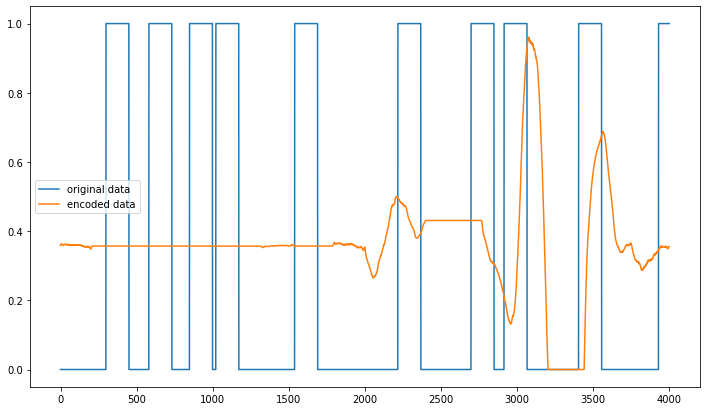

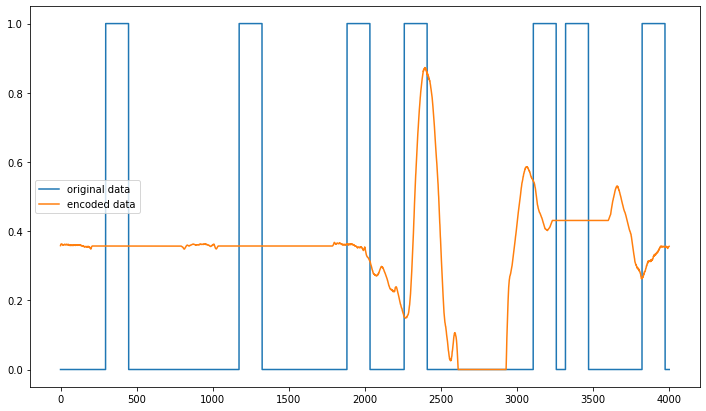

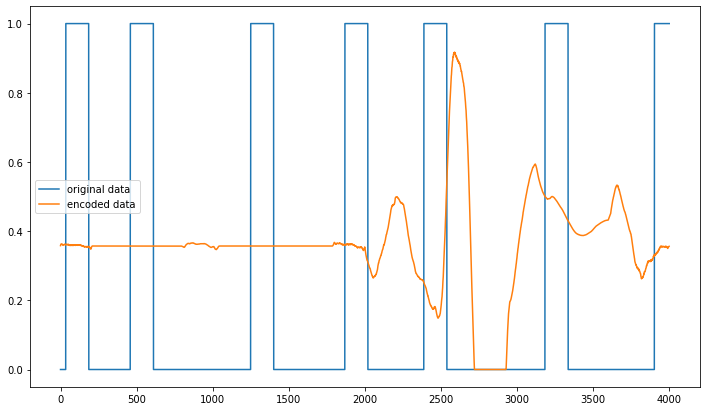

In [15]:
#encoded=fcn.predict(traindata)
for n in np.random.randint(0,5000,size=(3,)):
    encoded_=encoded[n]
    enc_plot=np.concatenate((encoded_[0],encoded_[1]))
    plt.plot(Datas[0][n],label='original data')
    plt.plot(enc_plot,label='encoded data')
    plt.legend()
    plt.show()

In any case we can look at what the network found

# 29th of June: Using the 8001 Data 

In [16]:
Datas8k=binaryalldirections8000()

In [22]:
mod8k,e8k,d8k=cnn8k()
traindata8k=fcndata8k(Datas8k[0],0)

In [ ]:
training(mod8k,0.0006,00,5,traindata8k,1,1)

Epoch 1/5
133/133 [==============================] - 107s 804ms/step - loss: 0.2454 - val_loss: 0.2308
Epoch 2/5
133/133 [==============================] - 107s 804ms/step - loss: 0.2292 - val_loss: 0.2273
Epoch 3/5
133/133 [==============================] - 106s 800ms/step - loss: 0.2271 - val_loss: 0.2262
Epoch 4/5
133/133 [==============================] - 107s 804ms/step - loss: 0.2263 - val_loss: 0.2255
Epoch 5/5
133/133 [==============================] - 107s 803ms/step - loss: 0.2258 - val_loss: 0.2249


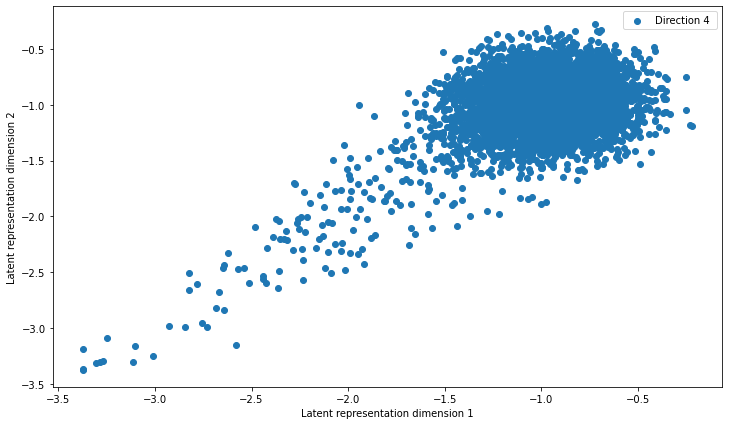

In [ ]:
traindataforplot=traindata8k.astype(np.float32)
_=latrep(e8k,traindataforplot,'Direction 4 ')

In [ ]:
encoded=fcn8k.predict(traindata8k)
for n in np.random.randint(0,5000,size=(3,)):
    encoded_=encoded[n]
    enc_plot=np.concatenate((encoded_[0],encoded_[1]))
    plt.plot(Datas8k[0][n],label='original data')
    plt.plot(enc_plot,label='encoded data')
    plt.legend()
    plt.show()

# 29th of June: Removing the high width data

In [20]:
def removehighwidths_binary(df,treshold):
    problems=[]
    for sample_n in range(len(df)):
        indexupl=[]
        indexdownl=[]
        arrayleft=df[sample_n]
        for n in range(len(arrayleft)-1):
            if (arrayleft[n+1]-arrayleft[n])==1:
                indexupl.append(n)       
            if (arrayleft[n+1]-arrayleft[n])==-1:
                indexdownl.append(n)
        if (len(indexupl)>0 and len(indexdownl)>0):
            if indexupl[0]>indexdownl[0]:
                i=1
            else:
                i=0
            for m in range(len(indexdownl)-i):
                if (indexdownl[m+i]-indexupl[m])>treshold:
                    problems.append(sample_n)
        else:
            problems.append(sample_n)
    mask = np.ones(len(df), np.bool)
    mask[problems] = 0
    data_new = df[mask]
    return data_new,problems,mask
       

In [24]:

d8knew,problems,noproblems=removehighwidths_binary(Datas8k[0],250)          
model8k,en8k,de8k=cnn8k()
print(np.shape(d8knew))
print(d8knew[0])
print(noproblems[0])
traindata8k=fcndata8k(d8knew,0) 

(4590, 8001)
[0 0 0 ... 0 0 0]
True


In [25]:
training(model8k,0.0006,200,10,traindata8k,1,1)

Epoch 1/10
19/19 [==============================] - 82s 4s/step - loss: 0.2910 - val_loss: 0.2528
Epoch 2/10
19/19 [==============================] - 82s 4s/step - loss: 0.2460 - val_loss: 0.2432
Epoch 3/10
19/19 [==============================] - 82s 4s/step - loss: 0.2409 - val_loss: 0.2397
Epoch 4/10
19/19 [==============================] - 82s 4s/step - loss: 0.2374 - val_loss: 0.2357
Epoch 5/10
19/19 [==============================] - 83s 4s/step - loss: 0.2333 - val_loss: 0.2319
Epoch 6/10
19/19 [==============================] - 83s 4s/step - loss: 0.2299 - val_loss: 0.2291
Epoch 7/10
19/19 [==============================] - 84s 4s/step - loss: 0.2278 - val_loss: 0.2273
Epoch 8/10
19/19 [==============================] - 82s 4s/step - loss: 0.2266 - val_loss: 0.2264
Epoch 9/10
19/19 [==============================] - 82s 4s/step - loss: 0.2258 - val_loss: 0.2258
Epoch 10/10
19/19 [==============================] - 82s 4s/step - loss: 0.2253 - val_loss: 0.2254


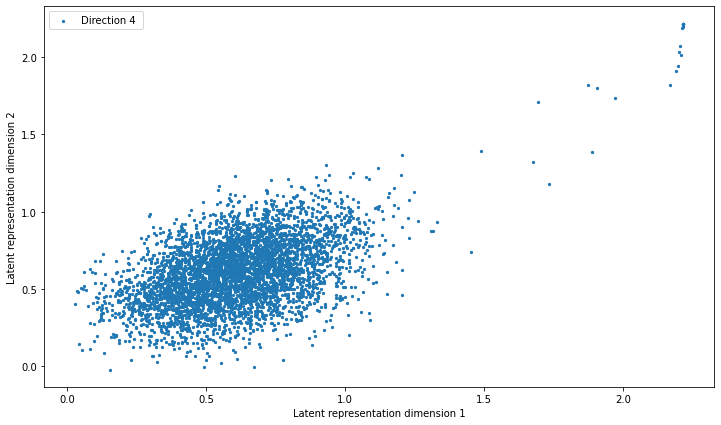

In [28]:
traindataforplot=traindata8k.astype(np.float32)
a,b=latrep(en8k,traindataforplot,'Direction 4 ')

In [32]:
indices=[]
for n in range(len(a)):
    if a[n]>1.4:
        indices.append(n)


24
63


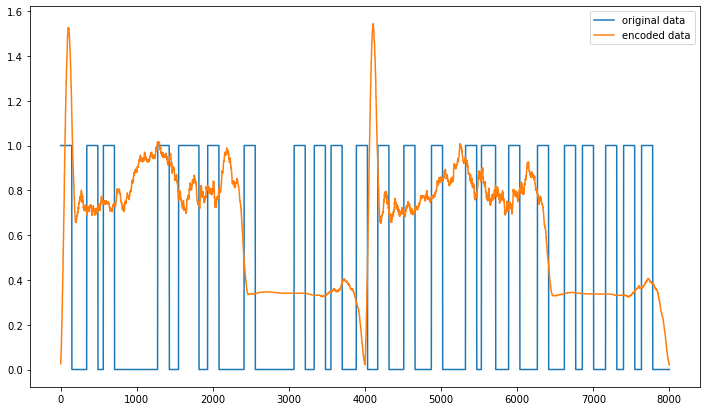

259


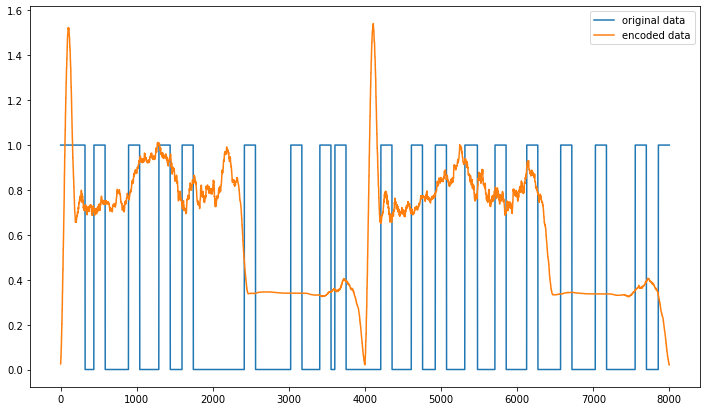

323


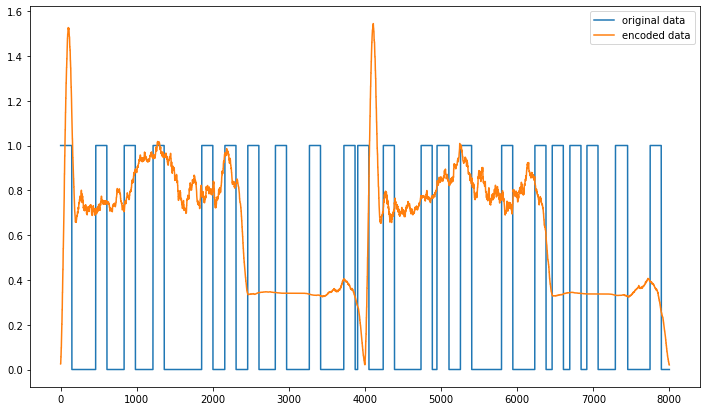

391


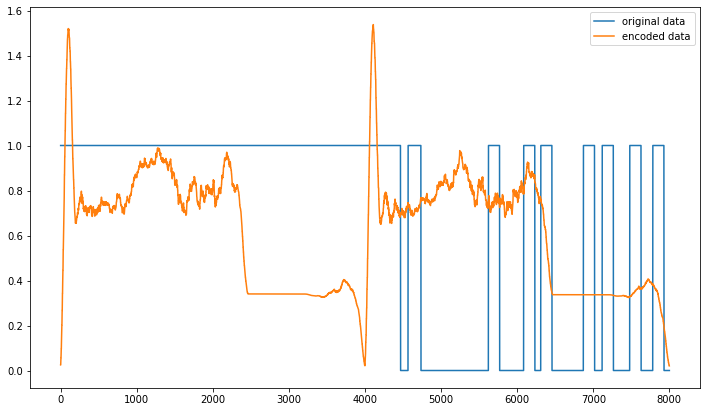

890


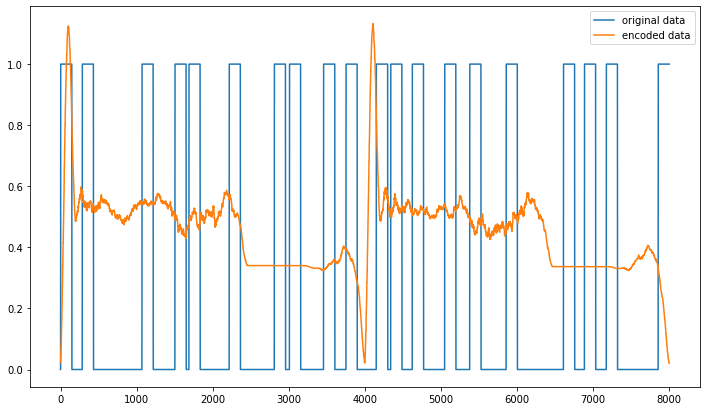

928


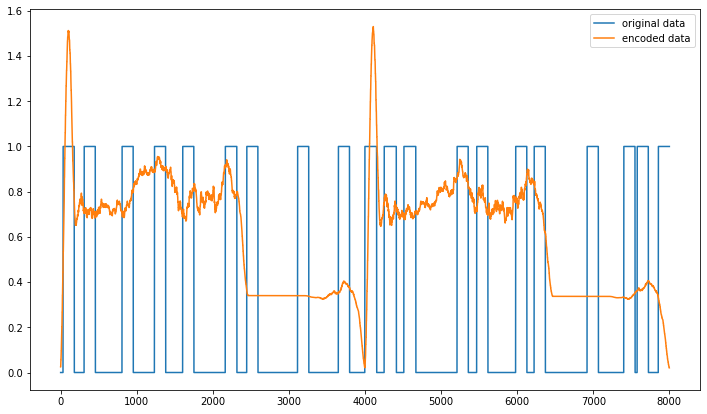

1233


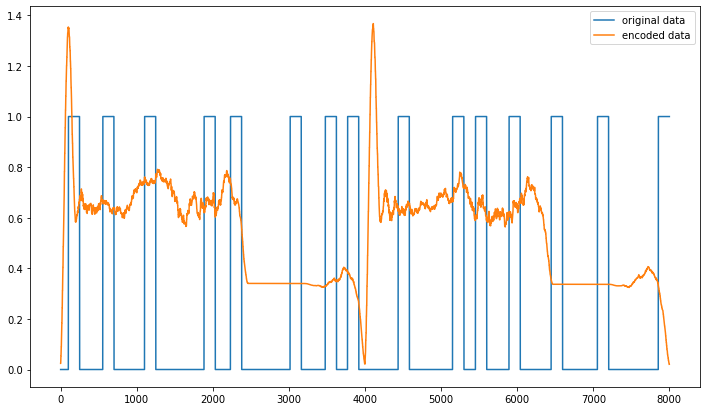

1240


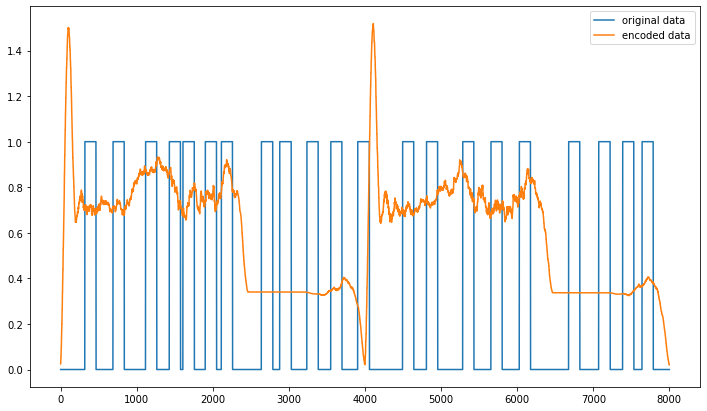

1362


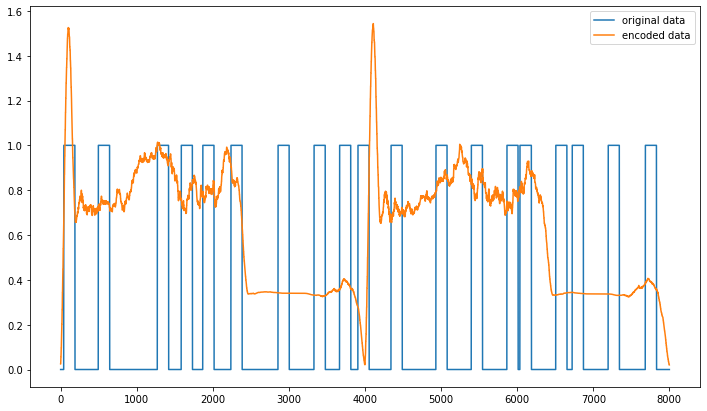

1454


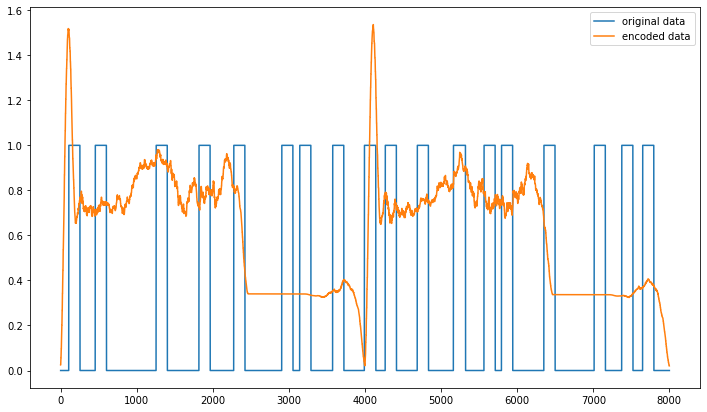

1455


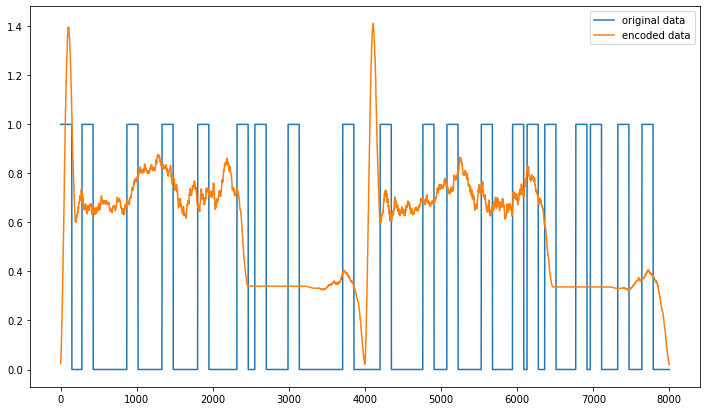

1652


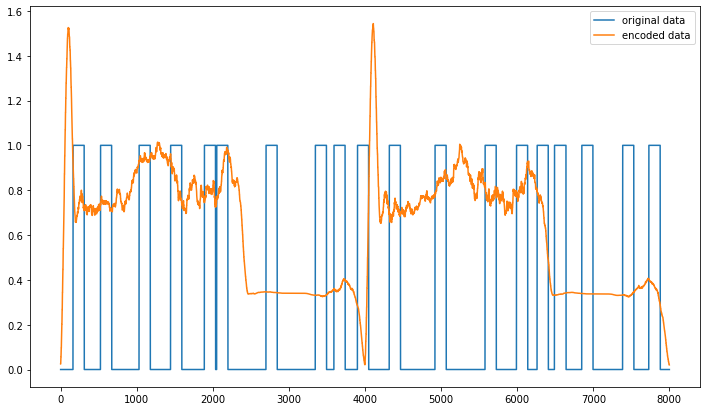

2054


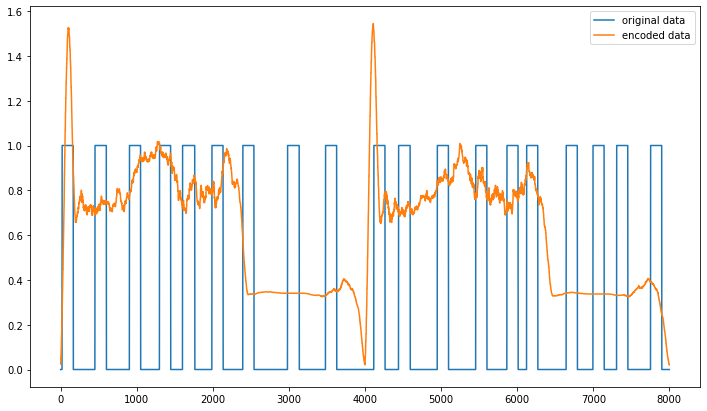

2239


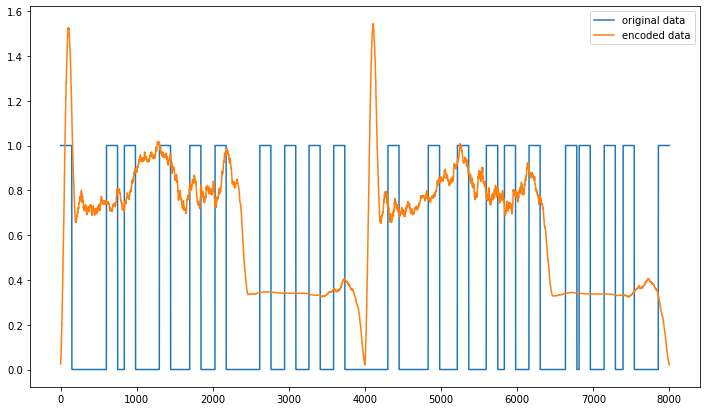

2574


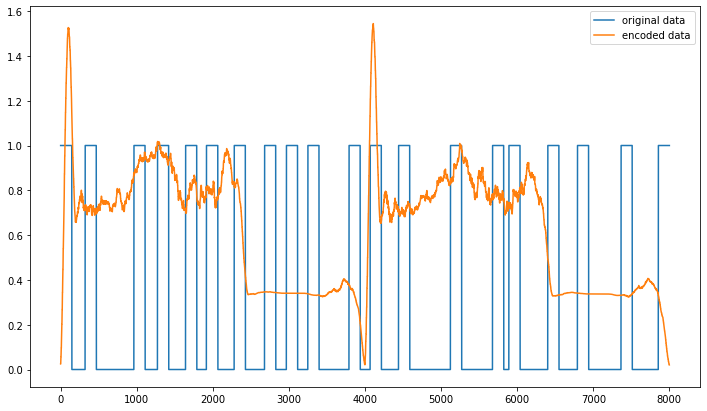

2586


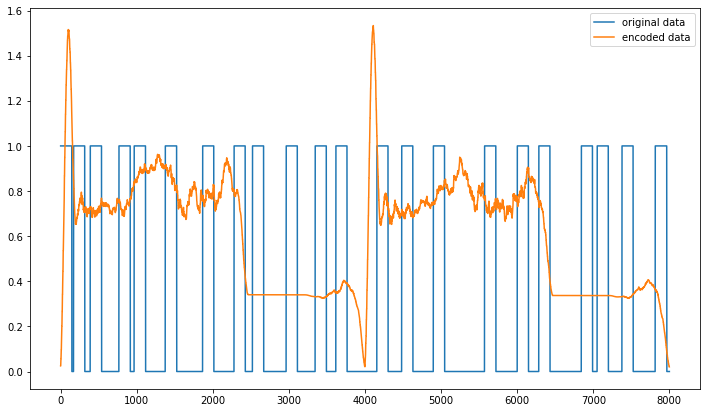

2643


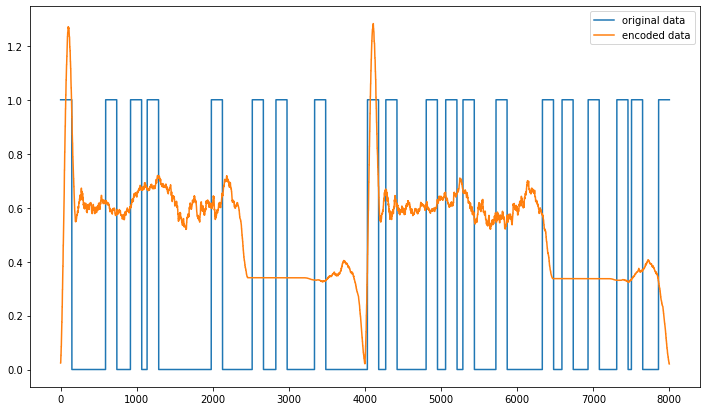

3486


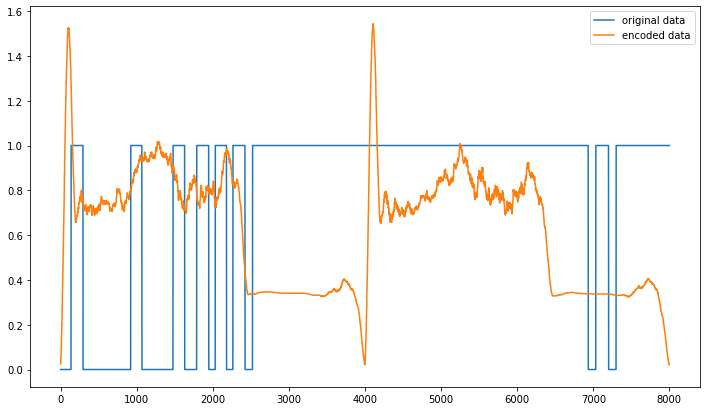

3977


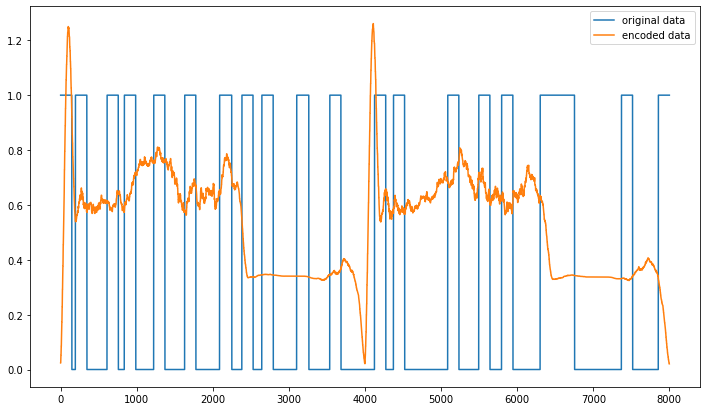

4298


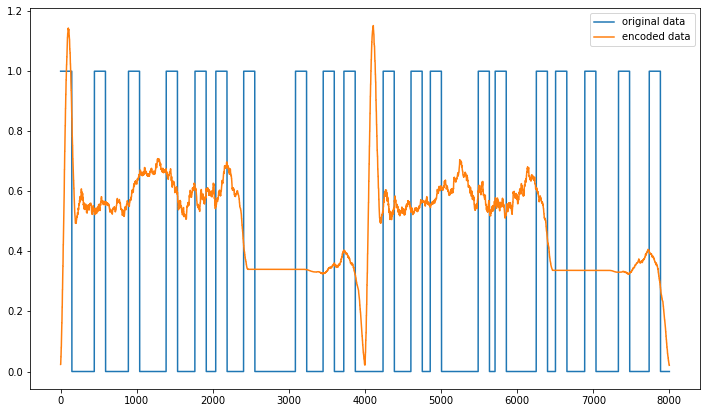

4300


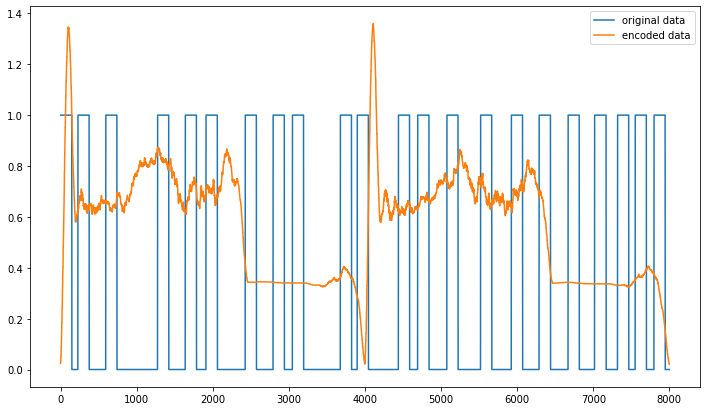

4376


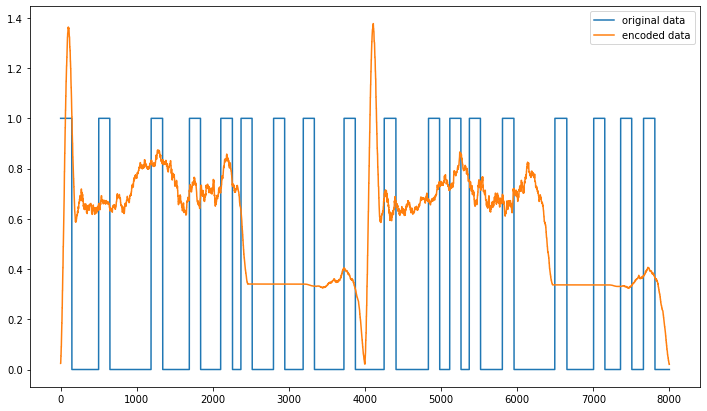

4385


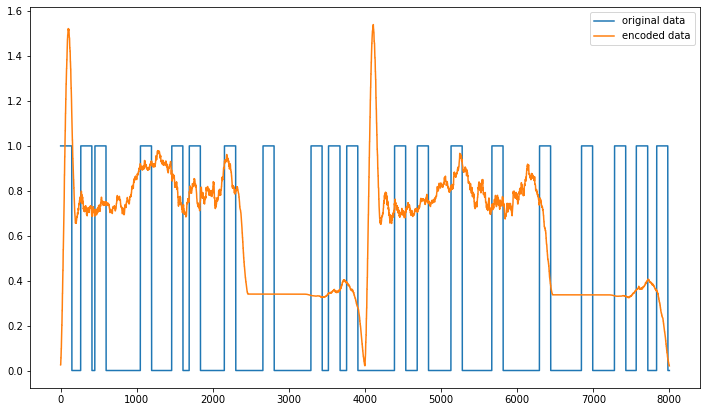

4547


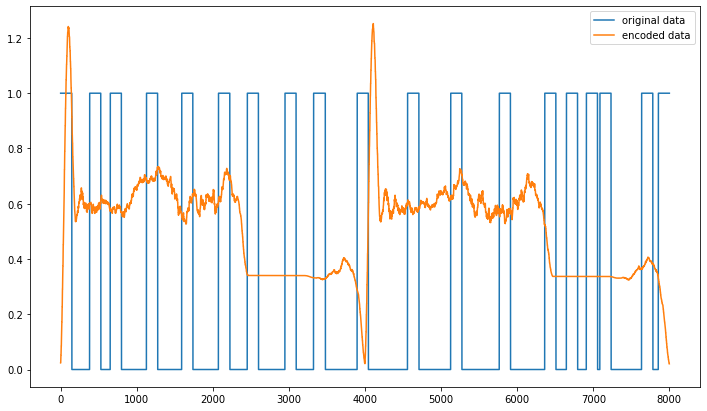

In [34]:
print(len(indices))
for n in indices:
    print(n)
    encoded_=encoded[n]
    enc_plot=np.concatenate((encoded_[0],encoded_[1]))
    plt.plot(Datas8k[0][n],label='original data')
    plt.plot(enc_plot,label='encoded data')
    plt.legend()
    plt.show()

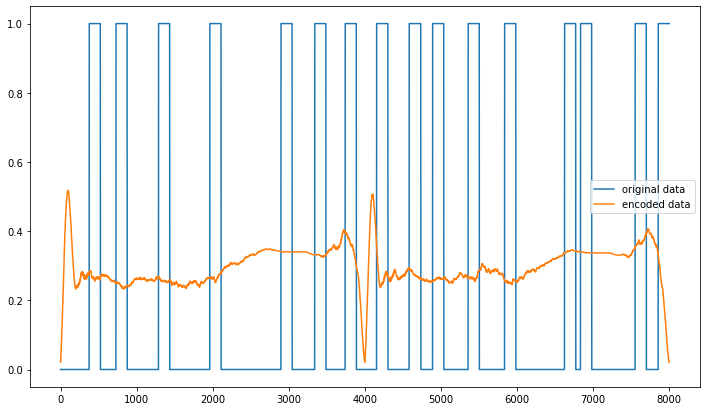

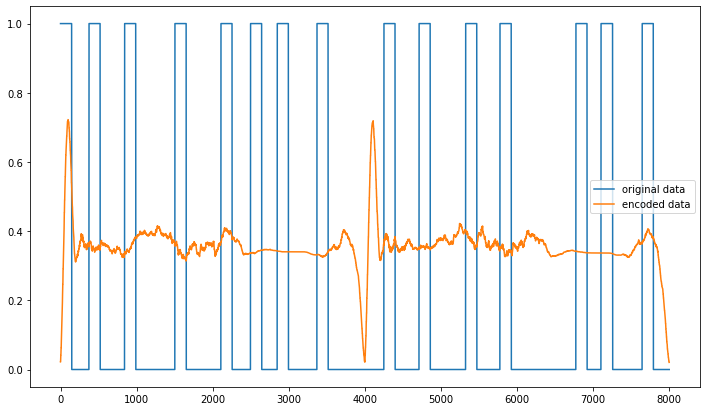

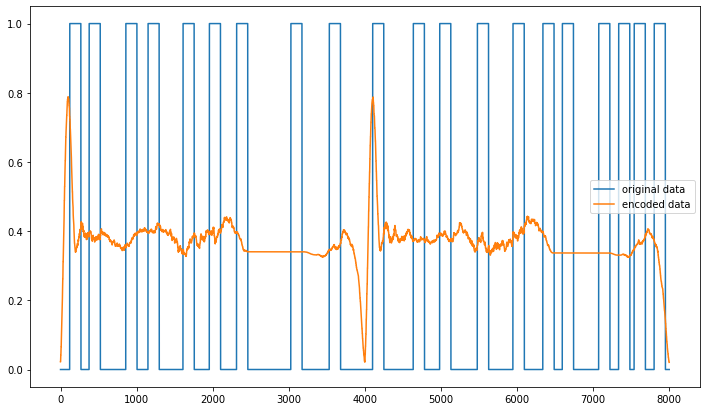

In [30]:
#encoded=model8k.predict(traindata8k)
for n in np.random.randint(0,5000,size=(3,)):
    encoded_=encoded[n]
    enc_plot=np.concatenate((encoded_[0],encoded_[1]))
    plt.plot(Datas8k[0][n],label='original data')
    plt.plot(enc_plot,label='encoded data')
    plt.legend()
    plt.show()

# 30th June: Starting further outside

In [26]:
traindata8kout=fcndata8k(Datas8k[0],1500)

ValueError: ignored

In [ ]:
model8kout,e8ko,d3ko=cnn8k()

In [ ]:
training(model8kout,0.0006,150,10,traindata8kout,1,1)

In [ ]:
traindataforplot=traindata8kout.astype(np.float32)
_=latrep(e8k,traindataforplot,'Direction 4 ')

# Conclusion:
The FCN is not really suitable to detect something in the data, although it creates interesting shapes.